# Plane Waves at an Anisotropic Interface

`optiland.anisotropic.solve_interface` solves the boundary between two
homogeneous media, each given by its 6 × 6 constitutive matrix, for any
number of incident plane waves at once. It returns four children per wave:
two reflected (r1, r2) and two transmitted (t1, t2) modes, with their wave
vectors, fields, ray directions (the Poynting vectors), walk-off angles,
power fractions and 3 × 3 polarization ray-tracing (PRT) matrices.

This example checks the solver against the Fresnel equations for glass and
against the walk-off of calcite, and then plots the reflectance of a calcite
face over the angle of incidence.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.anisotropic import CHILD_LABELS, constitutive_matrix, solve_interface
from optiland.materials import IdealMaterial, UniaxialMaterial

wavelength = 0.5893  # µm
print("child order:", CHILD_LABELS)

child order: ('r1', 'r2', 't1', 't2')


## The isotropic limit: the Fresnel equations

Wave vectors are in units of k0 = 2π/λ, so an incident wave in air has
k = d̂. The plane of incidence is x–z; s is along y. For an isotropic exit
medium the solver labels the s-like child t1 and the p-like child t2.

In [2]:
air = constitutive_matrix(IdealMaterial(n=1.0), wavelength)
glass = constitutive_matrix(IdealMaterial(n=1.5), wavelength)

theta = np.radians(np.linspace(0.0, 89.0, 90))
k_in = np.stack([np.sin(theta), 0 * theta, np.cos(theta)], axis=1)
e_s = np.tile([0.0, 1.0, 0.0], (theta.size, 1))
e_p = np.stack([np.cos(theta), 0 * theta, -np.sin(theta)], axis=1)
normal = [0.0, 0.0, 1.0]

r_s = solve_interface(normal, air, glass, k_in, e_s).reflectance
r_p = solve_interface(normal, air, glass, k_in, e_p).reflectance

n = 1.5
root = np.sqrt(n**2 - np.sin(theta) ** 2)
fresnel_s = ((np.cos(theta) - root) / (np.cos(theta) + root)) ** 2
fresnel_p = ((n**2 * np.cos(theta) - root) / (n**2 * np.cos(theta) + root)) ** 2
print(f"max |R_s - Fresnel| = {np.max(np.abs(r_s - fresnel_s)):.1e}")
print(f"max |R_p - Fresnel| = {np.max(np.abs(r_p - fresnel_p)):.1e}")
print(
    f"Brewster angle: {np.degrees(theta[np.argmin(r_p)]):.0f} deg "
    f"(arctan 1.5 = {np.degrees(np.arctan(n)):.2f} deg)"
)

max |R_s - Fresnel| = 7.5e-15
max |R_p - Fresnel| = 1.5e-14
Brewster angle: 56 deg (arctan 1.5 = 56.31 deg)


## Walk-off in calcite

A wave at normal incidence on a calcite plate whose optic axis lies at 45°
in the x–z plane splits into an ordinary wave and an extraordinary wave. Both
wave vectors are normal to the face, but the extraordinary ray (the energy
flow) leaves at the walk-off angle ρ, with
tan ρ = (n² / 2) (1/n_e² − 1/n_o²) sin 2θ and
1/n² = cos²θ / n_o² + sin²θ / n_e² at the angle θ = 45° between the wave
normal and the optic axis.

In [3]:
n_o, n_e = 1.6583434042, 1.4861300612  # calcite at 589.3 nm (Ghosh 1999)
calcite = UniaxialMaterial(
    IdealMaterial(n_o), IdealMaterial(n_e), optic_axis=(1.0, 0.0, 1.0)
)
crystal = constitutive_matrix(calcite, wavelength)

result = solve_interface(normal, air, crystal, [0.0, 0.0, 1.0], [1.0, 0.0, 0.0])
t = np.radians(45.0)
n_theta = 1.0 / np.sqrt(np.cos(t) ** 2 / n_o**2 + np.sin(t) ** 2 / n_e**2)
rho = np.arctan(n_theta**2 / 2 * (1 / n_e**2 - 1 / n_o**2) * np.sin(2 * t))

for j, label in enumerate(CHILD_LABELS):
    print(
        f"{label}: power {round(float(result.power[0, j]), 9) + 0.0:.6f}  "
        f"ray {np.round(result.ray[0, j], 6) + 0.0}  "
        f"walk-off {np.degrees(result.walkoff[0, j]):.6f} deg"
    )
print(f"closed form: walk-off {np.degrees(rho):.6f} deg")
print(f"reflectance + transmittance - 1 = {result.balance[0]:.1e}")

r1: power 0.000000  ray [ 0.  0. -1.]  walk-off 0.000000 deg
r2: power 0.048544  ray [ 0.  0. -1.]  walk-off 0.000000 deg
t1: power 0.000000  ray [0. 0. 1.]  walk-off 0.000000 deg
t2: power 0.951456  ray [-0.108561  0.        0.99409 ]  walk-off 6.232370 deg
closed form: walk-off 6.232370 deg
reflectance + transmittance - 1 = 0.0e+00


The x-polarized input is the extraordinary wave of this cut, so all the
transmitted power is in one child. Each child also has a PRT matrix P_j:
P_j maps the incident field to the child field and the incident wave
direction to the child wave direction.

In [4]:
e_child = int(np.argmax(result.power[0, 2:])) + 2
P = result.prt[0, e_child]
print("P E_in  =", np.round(P @ np.array([1.0, 0.0, 0.0]), 6))
print("child E =", np.round(result.E[0, e_child], 6))
print("P k_in  =", np.round(P @ np.array([0.0, 0.0, 1.0]), 6))

P E_in  = [0.779674+0.j 0.      +0.j 0.085145+0.j]
child E = [0.779674+0.j 0.      +0.j 0.085145+0.j]
P k_in  = [0.+0.j 0.+0.j 1.+0.j]


## Reflectance of a calcite face

With the optic axis normal to the plane of incidence (along y), the s wave
(E along y) sees n_e and the p wave sees n_o, so each reflects as from an
isotropic medium of that index.

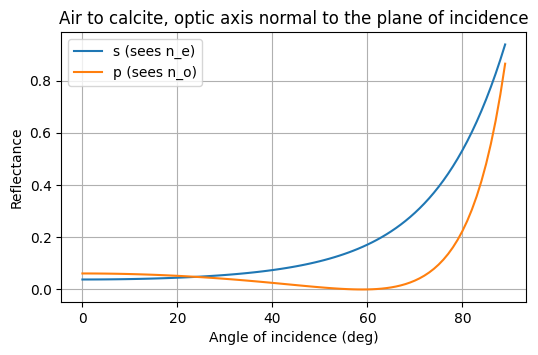

max |R_s - Fresnel(n_e)| = 7.7e-15


In [5]:
calcite_y = constitutive_matrix(
    UniaxialMaterial(
        IdealMaterial(n_o), IdealMaterial(n_e), optic_axis=(0.0, 1.0, 0.0)
    ),
    wavelength,
)
r_s = solve_interface(normal, air, calcite_y, k_in, e_s).reflectance
r_p = solve_interface(normal, air, calcite_y, k_in, e_p).reflectance

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(np.degrees(theta), r_s, label="s (sees n_e)")
ax.plot(np.degrees(theta), r_p, label="p (sees n_o)")
ax.set_xlabel("Angle of incidence (deg)")
ax.set_ylabel("Reflectance")
ax.set_title("Air to calcite, optic axis normal to the plane of incidence")
ax.legend()
ax.grid(True)
plt.show()

root_e = np.sqrt(n_e**2 - np.sin(theta) ** 2)
fresnel_s_e = ((np.cos(theta) - root_e) / (np.cos(theta) + root_e)) ** 2
print(f"max |R_s - Fresnel(n_e)| = {np.max(np.abs(r_s - fresnel_s_e)):.1e}")